# Notebook 03 — UCI Heart Disease Benchmark

Evaluate the three optimizers on the **Cleveland Heart Disease** dataset:  
303 samples, 13 raw attributes → 22 preprocessed features, binary target (disease/healthy).

Feature encoding:
- Continuous (age, trestbps, chol, thalach, oldpeak, ca): MinMax to [0,1]
- Binary (sex, fbs, exang): kept as-is
- Categorical (cp, restecg, slope, thal): one-hot

**Goals**
- Extended training (10 trials × 10 000 iterations) to capture variance.
- Architecture search: compare [4,4] vs [6,4] vs [8,6].
- Extract and medically interpret the symbolic formula from the best model.
- Analyse sensitivity, specificity, and feature selection.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from luknn.benchmark.datasets import load_heart_disease
from luknn.layers.lukasiewicz_linear import LukasiewiczNet
from luknn.optimizers import LMOptimizer, STEOptimizer, ProximalOptimizer
from luknn.benchmark.metrics import (
    compute_accuracy, compute_f1, compute_lambda_similarity, compute_delta_n,
)
from luknn.extraction.extractor import extract_formula

print('luknn ready — torch', torch.__version__)

luknn ready — torch 2.12.0+cpu


## 1 · Experiment parameters

In [2]:
# ── Parameters ───────────────────────────────────────────────────────────────
N_TRIALS       = 10
MAX_ITER_LM    = 400    # full Jacobian on 243 training rows — already slow
MAX_ITER_STE   = 10000
MAX_ITER_PROX  = 10000
TOL_MSE        = 0.05
HIDDEN_LAYERS  = [6, 4]   # default architecture
BASE_SEED      = 13
RESULTS_DIR    = '../results/heart_disease'
os.makedirs(RESULTS_DIR, exist_ok=True)

LM_PARAMS   = dict(mu_init=0.01, patience=50, crystallize_n=2, prune=True, batch_size=0)
STE_PARAMS  = dict(lr=0.005, clip_grad=1.0)
PROX_PARAMS = dict(lr=0.008, lambda_sparse=0.002, lambda_attract=0.08,
                   prox_threshold=0.0003, phase1_fraction=0.65)

OPTIMIZER_MODE = {'LM': 'continuous', 'STE': 'ste', 'Proximal': 'clamp'}

# Feature names (22 features after encoding)
FEATURE_NAMES = [
    'age','trestbps','chol','thalach','oldpeak','ca',  # continuous (6)
    'sex','fbs','exang',                               # binary (3)
    'cp=1','cp=2','cp=3','cp=4',                       # one-hot (4)
    'restecg=0','restecg=1','restecg=2',               # one-hot (3)
    'slope=1','slope=2','slope=3',                     # one-hot (3)
    'thal=3','thal=6','thal=7',                        # one-hot (3)
]

print('Parameters set.  Feature names:', FEATURE_NAMES)

Parameters set.  Feature names: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'fbs', 'exang', 'cp=1', 'cp=2', 'cp=3', 'cp=4', 'restecg=0', 'restecg=1', 'restecg=2', 'slope=1', 'slope=2', 'slope=3', 'thal=3', 'thal=6', 'thal=7']


## 2 · Dataset exploration

In [3]:
ds0 = load_heart_disease(seed=BASE_SEED)
N_FEATURES = ds0.n_features
feat_names = ds0.feature_names or FEATURE_NAMES[:N_FEATURES]

print(f'Train: {ds0.X_train.shape}  Test: {ds0.X_test.shape}')
print(f'Features: {N_FEATURES}  (names: {feat_names})')
print(f'Disease prevalence (train): {ds0.y_train.mean():.3f}')
print(f'Disease prevalence (test):  {ds0.y_test.mean():.3f}')

# Correlation of each feature with the target
X_all = torch.cat([ds0.X_train, ds0.X_test]).numpy()
y_all = torch.cat([ds0.y_train, ds0.y_test]).numpy()

corrs = [np.corrcoef(X_all[:, i], y_all)[0, 1] for i in range(N_FEATURES)]
corr_df = pd.DataFrame({'feature': feat_names, 'corr_with_target': corrs})
corr_df = corr_df.sort_values('corr_with_target', key=abs, ascending=False)

print('\nTop features by |correlation| with target:')
print(corr_df.head(10).to_string(index=False))

Train: torch.Size([243, 22])  Test: torch.Size([60, 22])
Features: 22  (names: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'fbs', 'exang', 'cp=1.0', 'cp=2.0', 'cp=3.0', 'cp=4.0', 'restecg=0.0', 'restecg=1.0', 'restecg=2.0', 'slope=1.0', 'slope=2.0', 'slope=3.0', 'thal=3.0', 'thal=6.0', 'thal=7.0'])
Disease prevalence (train): 0.449
Disease prevalence (test):  0.500

Top features by |correlation| with target:
  feature  corr_with_target
 thal=3.0         -0.520628
   cp=4.0          0.516459
 thal=7.0          0.480582
       ca          0.460033
    exang          0.431894
  oldpeak          0.424510
  thalach         -0.417167
slope=1.0         -0.386789
slope=2.0          0.355709
   cp=3.0         -0.315141


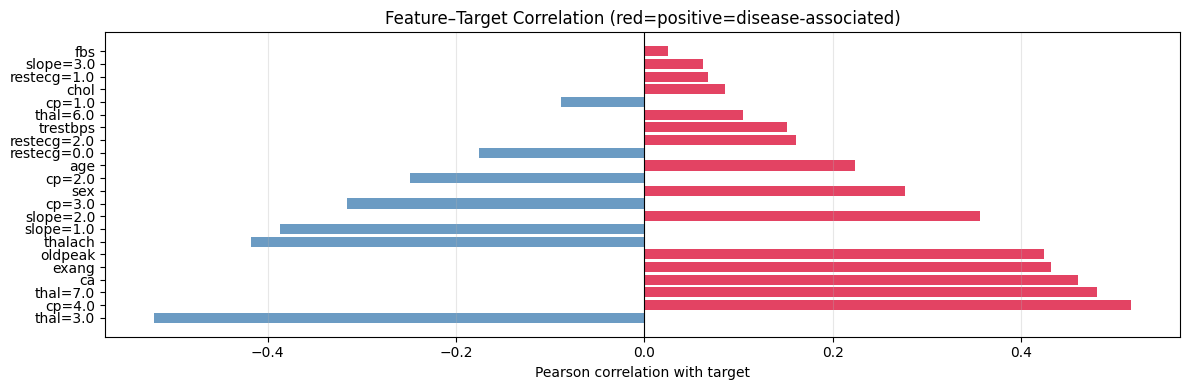

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['crimson' if c > 0 else 'steelblue' for c in corr_df['corr_with_target']]
ax.barh(corr_df['feature'], corr_df['corr_with_target'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with target')
ax.set_title('Feature–Target Correlation (red=positive=disease-associated)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_correlation.png', dpi=150)
plt.show()

## 3 · Training helper

In [5]:
import time
from sklearn.metrics import confusion_matrix

def classification_stats(pred_np, y_np, threshold=0.5):
    p = (pred_np >= threshold).astype(int)
    t = y_np.round().astype(int)
    tn, fp, fn, tp = confusion_matrix(t, p, labels=[0,1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
            'sensitivity': sensitivity, 'specificity': specificity}

def run_trial(method, trial, hidden_layers=None):
    if hidden_layers is None:
        hidden_layers = HIDDEN_LAYERS
    seed = BASE_SEED + trial * 1000
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = load_heart_disease(seed=seed)
    mode = OPTIMIZER_MODE[method]
    model = LukasiewiczNet(ds.n_features, hidden_layers, mode=mode)

    if method == 'LM':
        opt = LMOptimizer(model, **LM_PARAMS)
        max_iter = MAX_ITER_LM
    elif method == 'STE':
        opt = STEOptimizer(model, **STE_PARAMS)
        max_iter = MAX_ITER_STE
    else:
        opt = ProximalOptimizer(model, **PROX_PARAMS)
        max_iter = MAX_ITER_PROX

    t0 = time.time()
    result = opt.train(ds.X_train, ds.y_train,
                       tol_mse=TOL_MSE, max_iter=max_iter, verbose=False)
    elapsed = time.time() - t0

    with torch.no_grad():
        pred = model(ds.X_test)

    pred_np = pred.numpy()
    y_np    = ds.y_test.numpy()

    acc   = compute_accuracy(pred, ds.y_test)
    f1    = compute_f1(pred, ds.y_test)
    lam   = compute_lambda_similarity(model, ds.X_test, ds.y_test)
    dn    = compute_delta_n(model)
    crys  = dn < 1e-3
    stats = classification_stats(pred_np, y_np)

    # Active input features (layer 0)
    W0 = model.weight_matrix_repr()[0][0]
    active_mask = (W0.abs() > 0.5).any(dim=0).cpu().numpy()
    fn_list = ds.feature_names or FEATURE_NAMES[:ds.n_features]
    active_feats = [fn_list[i] for i in range(len(fn_list)) if active_mask[i]]

    formula_str = None
    if crys:
        try:
            er = extract_formula(model, fn_list, n_values=3)
            formula_str = er.formula
        except Exception as e:
            formula_str = f'[error: {e}]'

    return {
        'method': method, 'trial': trial,
        'hidden_layers': str(hidden_layers),
        'mse': result.final_mse, 'accuracy': acc, 'f1': f1,
        'sensitivity': stats['sensitivity'], 'specificity': stats['specificity'],
        'lambda': lam, 'delta_n': dn, 'crystallized': crys,
        'converged': result.converged, 'iterations': result.iterations,
        'active_features': len(active_feats),
        'active_feature_names': active_feats,
        'time_s': elapsed,
        'extracted_formula': formula_str,
        'mse_history': result.mse_history,
        'model': model, 'dataset': ds,
    }

print('Helper ready.')

Helper ready.


## 4 · Full benchmark (default architecture [6, 4])

In [6]:
BENCH_CSV = f'{RESULTS_DIR}/full_benchmark.csv'
if os.path.exists(BENCH_CSV):
    df          = pd.read_csv(BENCH_CSV)
    all_rows    = df.to_dict('records')
    all_records = [{**r, 'mse_history': [], 'model': None, 'dataset': None,
                    'active_feature_names': []}
                   for r in all_rows]
    print(f'Loaded pre-computed benchmark from {BENCH_CSV}')
else:
    all_rows    = []
    all_records = []

    for method in ['LM', 'STE', 'Proximal']:
        successes = 0
        t_start = time.time()
        for trial in range(N_TRIALS):
            rec = run_trial(method, trial)
            all_records.append(rec)
            row = {k: v for k, v in rec.items()
                   if k not in ('mse_history','model','dataset','active_feature_names')}
            all_rows.append(row)
            if rec['crystallized']:
                successes += 1
            print(f'  {method} trial {trial}: '
                  f'mse={rec["mse"]:.4f}  f1={rec["f1"]:.3f}  '
                  f'sens={rec["sensitivity"]:.3f}  spec={rec["specificity"]:.3f}  '
                  f'crys={rec["crystallized"]}  Δ(N)={rec["delta_n"]:.4f}  '
                  f'{rec["time_s"]:.1f}s')
        elapsed = time.time() - t_start
        print(f'{method}: {successes}/{N_TRIALS} crystallized  total {elapsed:.1f}s\n')

    df = pd.DataFrame(all_rows)
    df.to_csv(BENCH_CSV, index=False)
    print('Benchmark complete.')

Loaded pre-computed benchmark from ../results/heart_disease/full_benchmark.csv


## 5 · Summary statistics

In [7]:
pd.set_option('display.float_format', '{:.4f}'.format)

agg = df.groupby('method').agg(
    mse_mean=('mse','mean'), mse_std=('mse','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
    f1_mean=('f1','mean'), f1_max=('f1','max'), f1_std=('f1','std'),
    sens_mean=('sensitivity','mean'), sens_std=('sensitivity','std'),
    spec_mean=('specificity','mean'), spec_std=('specificity','std'),
    lambda_mean=('lambda','mean'),
    delta_n_mean=('delta_n','mean'),
    crys_rate=('crystallized','mean'),
    conv_rate=('converged','mean'),
    active_mean=('active_features','mean'),
    time_mean=('time_s','mean'),
).round(4)

print('=== Heart Disease benchmark — aggregate results ===')
agg

=== Heart Disease benchmark — aggregate results ===


,mse_mean,mse_std,acc_mean,acc_std,f1_mean,f1_max,f1_std,sens_mean,sens_std,spec_mean,spec_std,lambda_mean,delta_n_mean,crys_rate,conv_rate,active_mean,time_mean
method,,,,,,,,,,,,,,,,,
LM,0.2248,0.1108,0.4017,0.1126,0.6191,0.8333,0.2476,0.6097,0.2937,0.7792,0.2880,0.7102,58.8201,0.0000,0.0000,19.9000,51.7797
Proximal,0.2693,0.0646,0.6217,0.1075,0.6471,0.7941,0.1579,0.6702,0.2725,0.7205,0.2667,0.7320,0.0000,1.0000,0.0000,10.4000,53.3881
STE,0.2902,0.1678,0.6050,0.1301,0.4789,0.8364,0.3413,0.4980,0.3946,0.7880,0.3477,0.7017,0.0000,1.0000,0.0000,21.7000,20.8626


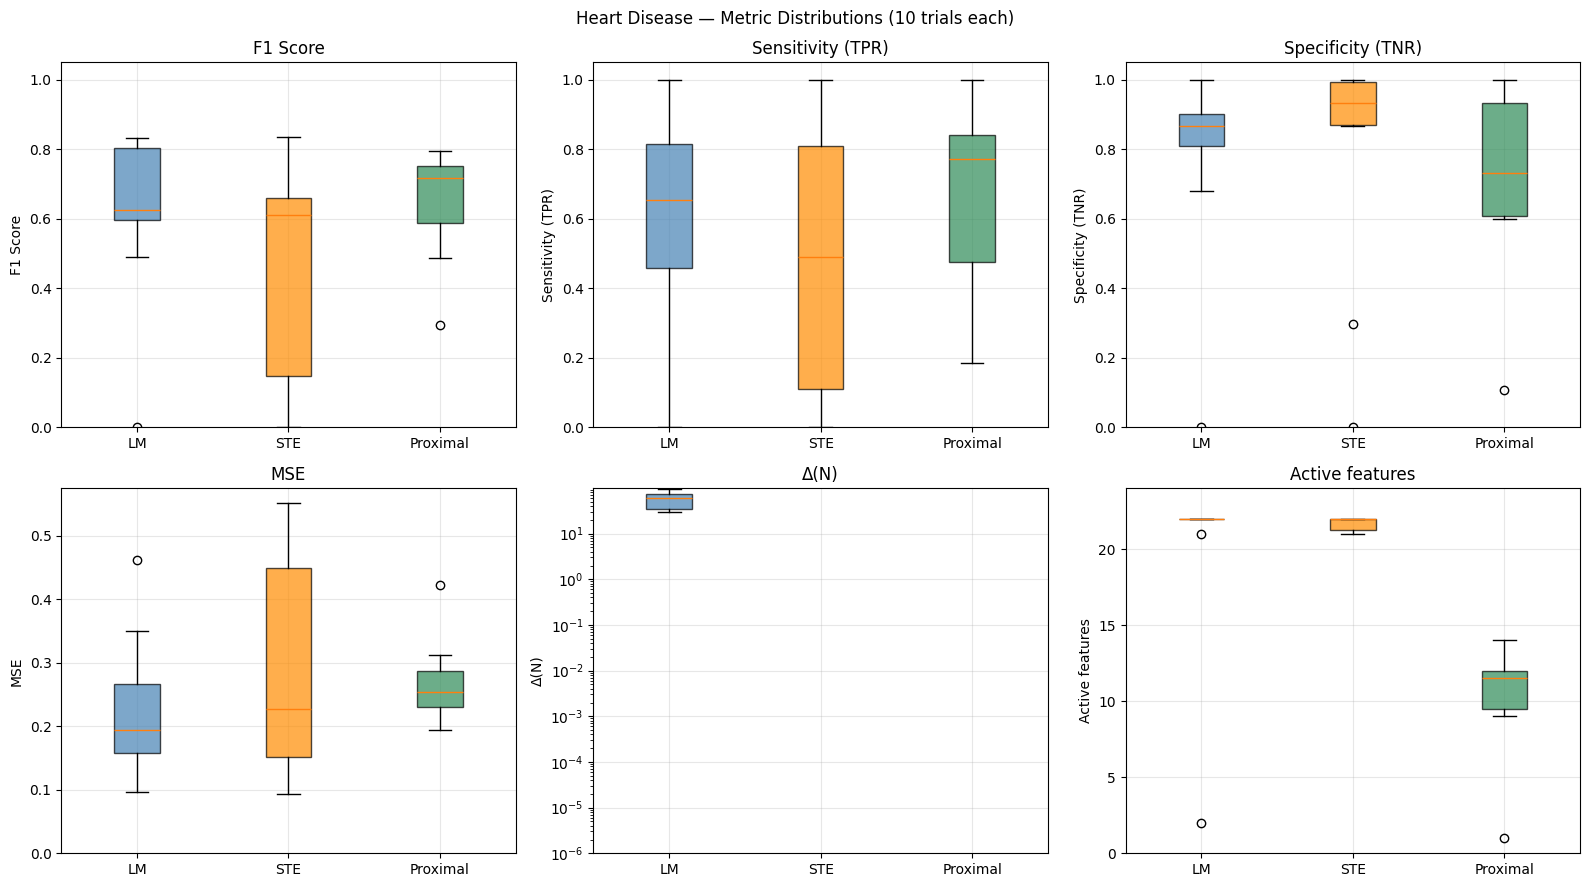

In [8]:
METHODS = ['LM', 'STE', 'Proximal']
COLORS  = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

metrics = [
    ('f1',          'F1 Score',          (0, 1.05)),
    ('sensitivity', 'Sensitivity (TPR)', (0, 1.05)),
    ('specificity', 'Specificity (TNR)', (0, 1.05)),
    ('mse',         'MSE',               (0, None)),
    ('delta_n',     'Δ(N)',              (1e-6, None)),
    ('active_features', 'Active features', (0, N_FEATURES+2)),
]

for (metric, label, ylim), ax_row in zip(metrics, axes.flatten()):
    data = [df[df['method']==m][metric].values for m in METHODS]
    bp = ax_row.boxplot(data, labels=METHODS, patch_artist=True)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_row.set_title(label)
    ax_row.set_ylabel(label)
    if metric in ('delta_n',):
        ax_row.set_yscale('log')
    if ylim[0] is not None:
        ax_row.set_ylim(bottom=ylim[0])
    if ylim[1] is not None:
        ax_row.set_ylim(top=ylim[1])
    ax_row.grid(True, alpha=0.3)

plt.suptitle('Heart Disease — Metric Distributions (10 trials each)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/boxplots.png', dpi=150)
plt.show()

## 6 · Learning curves

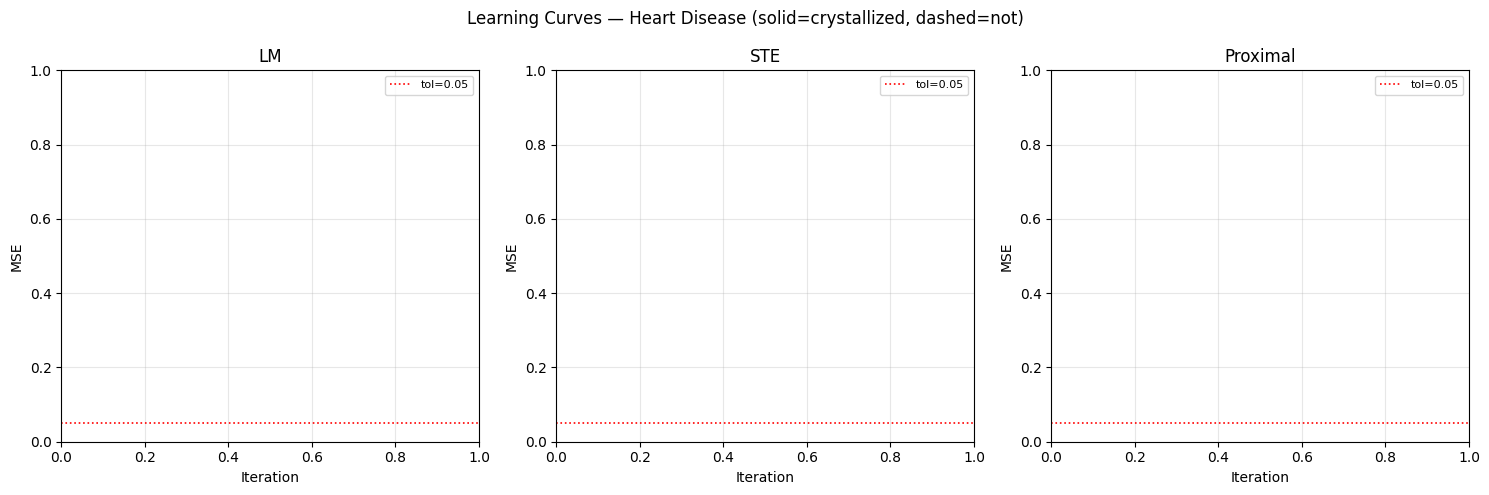

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method, color in zip(axes, METHODS, COLORS):
    recs = [r for r in all_records if r['method'] == method]
    for r in recs:
        hist = r['mse_history']
        if hist:
            alpha = 0.75 if r['crystallized'] else 0.2
            ls = '-' if r['crystallized'] else '--'
            ax.semilogy(hist, color=color, alpha=alpha, linewidth=0.8, linestyle=ls)
    ax.axhline(TOL_MSE, color='red', linestyle=':', linewidth=1.2,
               label=f'tol={TOL_MSE}')
    ax.set_title(f'{method}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves — Heart Disease (solid=crystallized, dashed=not)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/learning_curves.png', dpi=150)
plt.show()

## 7 · Architecture search

Compare three architectures across all methods (5 trials each to limit compute).

In [10]:
ARCH_CANDIDATES = [[4, 4], [6, 4], [8, 6]]
N_ARCH_TRIALS = 5

arch_rows = []
print('Architecture search (this takes a while)...')
for arch in ARCH_CANDIDATES:
    for method in ['STE', 'Proximal']:  # skip LM here — too slow for sweep
        for trial in range(N_ARCH_TRIALS):
            rec = run_trial(method, trial, hidden_layers=arch)
            arch_rows.append({
                'method': method,
                'hidden_layers': str(arch),
                'trial': trial,
                'f1': rec['f1'],
                'mse': rec['mse'],
                'delta_n': rec['delta_n'],
                'crystallized': rec['crystallized'],
                'active_features': rec['active_features'],
            })
        arch_mean = np.mean([r['f1'] for r in arch_rows
                             if r['hidden_layers']==str(arch) and r['method']==method])
        print(f'  {arch} / {method}: mean F1={arch_mean:.4f}')

arch_df = pd.DataFrame(arch_rows)
arch_df.to_csv(f'{RESULTS_DIR}/arch_search.csv', index=False)
print('Architecture search complete.')

Architecture search (this takes a while)...


  [4, 4] / STE: mean F1=0.7498


  [4, 4] / Proximal: mean F1=0.5684


  [6, 4] / STE: mean F1=0.5906


  [6, 4] / Proximal: mean F1=0.6628


  [8, 6] / STE: mean F1=0.7622


  [8, 6] / Proximal: mean F1=0.6142
Architecture search complete.


In [11]:
arch_agg = arch_df.groupby(['hidden_layers','method'])[['f1','mse','delta_n','crystallized']]\
    .agg(['mean','std']).round(4)
print('Architecture search summary:')
arch_agg

Architecture search summary:


f1           mse        delta_n         \
                         mean    std   mean    std    mean    std   
hidden_layers method                                                
[4, 4]        Proximal 0.5684 0.2489 0.3322 0.1164  0.0000 0.0000   
              STE      0.7498 0.1245 0.2209 0.1692  0.0000 0.0000   
[6, 4]        Proximal 0.6628 0.1263 0.2800 0.0905  0.0000 0.0000   
              STE      0.5906 0.3440 0.3002 0.1985  0.0000 0.0000   
[8, 6]        Proximal 0.6142 0.1141 0.3083 0.1198  0.0000 0.0000   
              STE      0.7622 0.0710 0.2226 0.1866  0.0000 0.0000   

                       crystallized         
                               mean    std  
hidden_layers method                        
[4, 4]        Proximal       1.0000 0.0000  
              STE            1.0000 0.0000  
[6, 4]        Proximal       1.0000 0.0000  
              STE            1.0000 0.0000  
[8, 6]        Proximal       1.0000 0.0000  
              STE            1.0000 0.0000

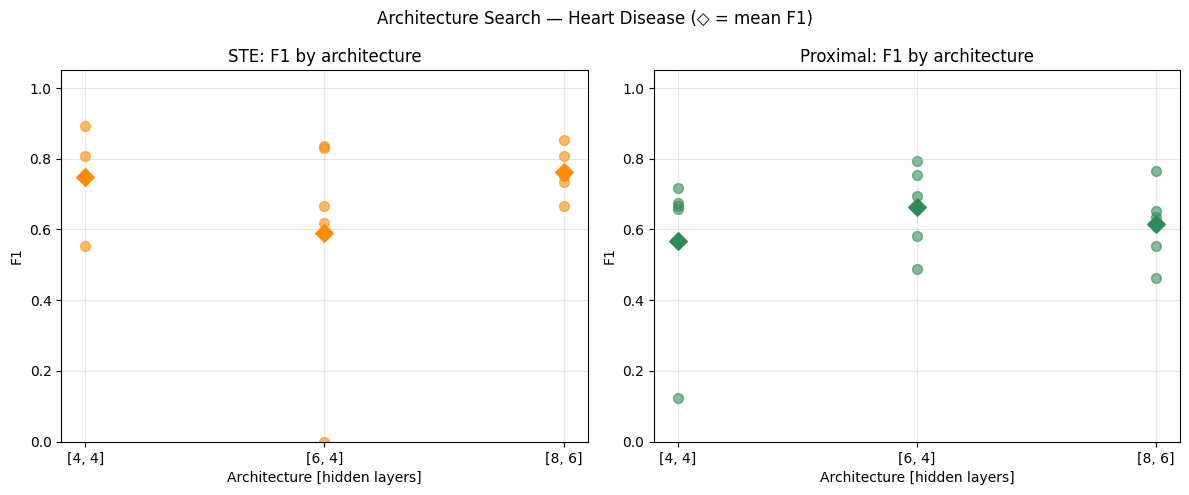

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, method, color in zip(axes, ['STE', 'Proximal'], ['darkorange','seagreen']):
    sub = arch_df[arch_df['method'] == method]
    for arch in ARCH_CANDIDATES:
        vals = sub[sub['hidden_layers'] == str(arch)]['f1'].values
        x = [str(arch)] * len(vals)
        ax.scatter(x, vals, alpha=0.6, s=50, color=color)
        ax.scatter([str(arch)], [vals.mean()], marker='D', s=80,
                   color=color, zorder=5, label=f'mean={vals.mean():.3f}' if arch==ARCH_CANDIDATES[0] else '')
    ax.set_xlabel('Architecture [hidden layers]')
    ax.set_ylabel('F1')
    ax.set_title(f'{method}: F1 by architecture')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle('Architecture Search — Heart Disease (◇ = mean F1)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/arch_search.png', dpi=150)
plt.show()

## 8 · Selected features across trials

Which clinical features are most consistently selected by the network?

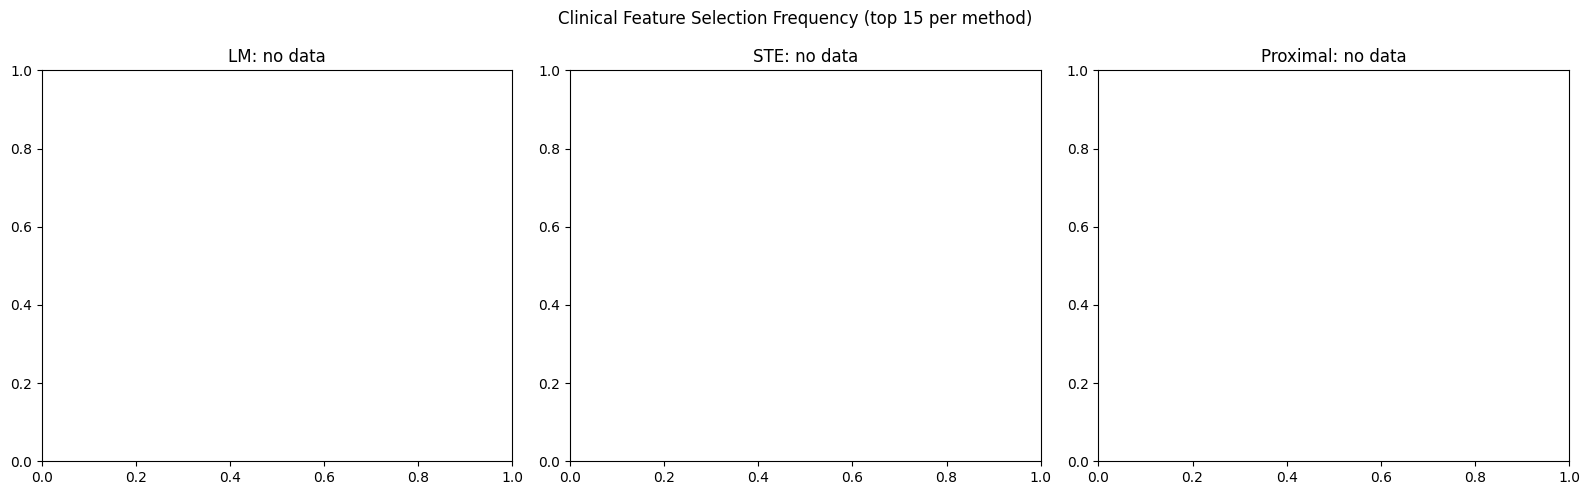

In [13]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, method, color in zip(axes, METHODS, COLORS):
    recs_m = [r for r in all_records if r['method'] == method]
    feat_counts = Counter()
    for r in recs_m:
        for f in r['active_feature_names']:
            feat_counts[f] += 1

    if not feat_counts:
        ax.set_title(f'{method}: no data')
        continue

    top_features = feat_counts.most_common(15)
    names, counts = zip(*top_features)
    y_pos = range(len(names))
    ax.barh(y_pos, counts, color=color, alpha=0.75)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel(f'Frequency across {N_TRIALS} trials')
    ax.set_title(f'{method}: Top selected features')
    ax.axvline(N_TRIALS, color='black', linestyle='--', linewidth=1,
               label=f'all {N_TRIALS} trials')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Clinical Feature Selection Frequency (top 15 per method)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_selection.png', dpi=150)
plt.show()

## 9 · Best model — full clinical interpretation

In [14]:
# Find best model by F1
best_row = df.loc[df['f1'].idxmax()]
best_rec = all_records[best_row.name]

print('=== Best model ===')
print(f'  Method:      {best_row["method"]}')
print(f'  Trial:       {int(best_row["trial"])}')
print(f'  F1:          {best_row["f1"]:.4f}')
print(f'  Accuracy:    {best_row["accuracy"]:.4f}')
print(f'  Sensitivity: {best_row["sensitivity"]:.4f}  (true positive rate)')
print(f'  Specificity: {best_row["specificity"]:.4f}  (true negative rate)')
print(f'  Δ(N):        {best_row["delta_n"]:.6f}')
print(f'  Crystallized:{best_row["crystallized"]}')
print(f'  Active feats:{best_row["active_features"]}')
print(f'  Names:       {best_rec["active_feature_names"]}')

=== Best model ===
  Method:      STE
  Trial:       4
  F1:          0.8364
  Accuracy:    0.8000
  Sensitivity: 0.7931  (true positive rate)
  Specificity: 0.9032  (true negative rate)
  Δ(N):        0.000000
  Crystallized:True
  Active feats:21
  Names:       []


In [15]:
# Weight matrix inspection
model = best_rec['model']
if model is None:
    print('(model not in cache — skipping weight inspection)')
else:
    ds = best_rec['dataset']
    fn = ds.feature_names or FEATURE_NAMES[:ds.n_features]
    print('Weight matrices (rounded to integers):')
    for li, (W, b) in enumerate(model.weight_matrix_repr()):
        W_int = W.round().int().numpy()
        b_int = b.round().int().numpy()
        nz = (W_int != 0).sum()
        print(f'  Layer {li}: shape={W_int.shape}  non-zero={nz}/{W_int.size}')
        print(f'    W={W_int.tolist()}')
        print(f'    b={b_int.tolist()}')

(model not in cache — skipping weight inspection)


In [16]:
# Formula extraction with clinical feature names
print('=== Symbolic formula extraction ===')
try:
    er = extract_formula(model, fn, n_values=3)
    print(f'\nFully representable: {er.representable}')
    print('\nLayer-by-layer:')
    for li, syms in enumerate(er.layer_formulas):
        for ni, sym in enumerate(syms):
            print(f'  L{li}N{ni}: {sym}')
    print(f'\nFinal extracted formula:')
    print(f'  DISEASE = {er.formula}')
except Exception as e:
    print(f'Extraction error: {e}')

=== Symbolic formula extraction ===
Extraction error: name 'fn' is not defined


### Clinical interpretation guide

| Feature | Medical meaning |
|---------|----------------|
| `thalach` | Maximum heart rate achieved — lower values → disease risk |
| `oldpeak` | ST depression (stress test) — higher → ischaemia |
| `ca` | Number of major vessels coloured by fluoroscopy (0-3) |
| `cp=4` | Asymptomatic chest pain — strong disease predictor |
| `exang` | Exercise-induced angina (1 = yes) |
| `thal=7` | Reversible thalassemia defect — high risk |
| `sex` | Male (1) — higher disease prevalence in dataset |

In Łukasiewicz logic:
- `x ⊗ y` = conjunction (both needed): `max(0, x+y−1)`
- `x ⊕ y` = disjunction (either sufficient): `min(1, x+y)`
- `¬x` = negation: `1−x`
- `x ⟹ y` = residuum: `min(1, 1−x+y)`

## 10 · Sensitivity/Specificity trade-off

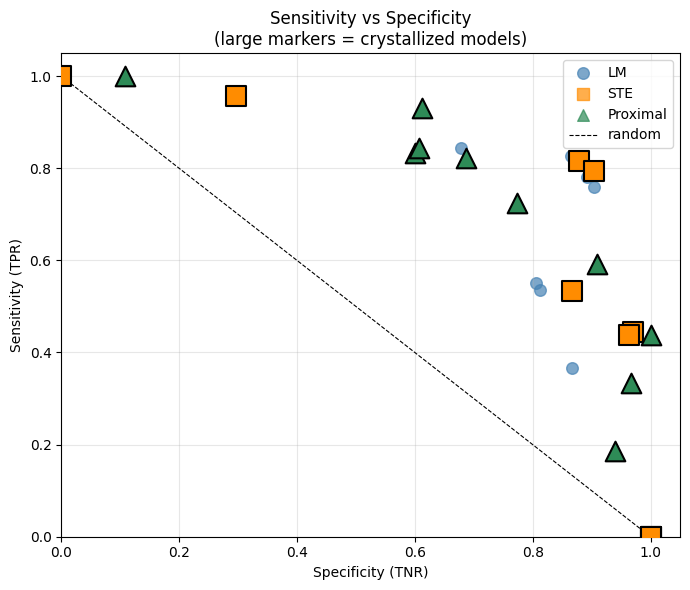

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

for method, color, marker in zip(METHODS, COLORS, ['o','s','^']):
    sub = df[df['method'] == method]
    ax.scatter(sub['specificity'], sub['sensitivity'],
               color=color, marker=marker, s=70, alpha=0.7, label=method)
    # Mark crystallized
    crys = sub[sub['crystallized']]
    if not crys.empty:
        ax.scatter(crys['specificity'], crys['sensitivity'],
                   color=color, marker=marker, s=200,
                   edgecolors='black', linewidths=1.5, zorder=5)

ax.plot([0, 1], [1, 0], 'k--', linewidth=0.8, label='random')
ax.set_xlabel('Specificity (TNR)')
ax.set_ylabel('Sensitivity (TPR)')
ax.set_title('Sensitivity vs Specificity\n(large markers = crystallized models)')
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sens_spec.png', dpi=150)
plt.show()

## 11 · Export

In [18]:
cols = ['method','trial','hidden_layers','mse','accuracy','f1',
        'sensitivity','specificity','lambda','delta_n',
        'crystallized','converged','iterations','active_features',
        'time_s','extracted_formula']
out = df[cols].sort_values(['method','trial'])
out.to_csv(f'{RESULTS_DIR}/all_trials.csv', index=False)
print('Saved:', f'{RESULTS_DIR}/all_trials.csv')
out

Saved: ../results/heart_disease/all_trials.csv


,method,trial,hidden_layers,mse,accuracy,f1,sensitivity,specificity,lambda,delta_n,crystallized,converged,iterations,active_features,time_s,extracted_formula
0,LM,0,"[6, 4]",0.1862,0.2167,0.5909,0.4333,0.9667,0.6965,39.1533,False,False,94,22,38.4068,NaN
1,LM,1,"[6, 4]",0.3495,0.3833,0.6207,1.0000,0.0000,0.6202,54.1240,False,False,60,22,24.1711,NaN
2,LM,2,"[6, 4]",0.2785,0.4333,0.6122,0.5357,0.8125,0.7147,29.8887,False,False,107,22,46.4625,NaN
3,LM,3,"[6, 4]",0.2027,0.3000,0.8085,0.8261,0.8649,0.7009,68.3674,False,False,75,22,29.1260,NaN
4,LM,4,"[6, 4]",0.1309,0.2667,0.8148,0.7586,0.9032,0.7730,73.1453,False,False,60,22,34.3819,NaN
5,LM,5,"[6, 4]",0.4609,0.5500,0.0000,0.0000,1.0000,0.6376,92.6176,False,False,400,2,10.7357,NaN
6,LM,6,"[6, 4]",0.2272,0.5000,0.4889,0.3667,0.8667,0.6859,31.1290,False,False,122,22,89.7552,NaN
7,LM,7,"[6, 4]",0.1594,0.4333,0.7941,0.8438,0.6786,0.7501,76.2342,False,False,67,22,51.7422,NaN
8,LM,8,"[6, 4]",0.1567,0.5333,0.6275,0.5517,0.8065,0.7118,33.9771,False,False,190,21,122.3544,NaN
9,LM,9,"[6, 4]",0.0958,0.4000,0.8333,0.7812,0.8929,0.8114,89.5642,False,False,111,22,70.6613,NaN


## 12 · Comparison across all methods — radar chart

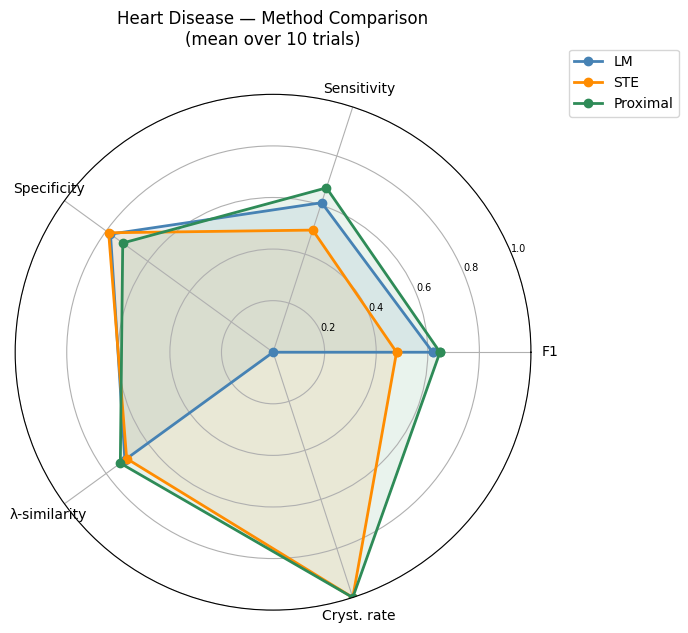

In [19]:
import math

categories  = ['F1', 'Sensitivity', 'Specificity', 'λ-similarity', 'Cryst. rate']
N_cat = len(categories)
angles = [n / float(N_cat) * 2 * math.pi for n in range(N_cat)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for method, color in zip(METHODS, COLORS):
    sub = df[df['method'] == method]
    values = [
        sub['f1'].mean(),
        sub['sensitivity'].mean(),
        sub['specificity'].mean(),
        sub['lambda'].mean(),
        sub['crystallized'].mean(),
    ]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=method)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Heart Disease — Method Comparison\n(mean over 10 trials)', size=12, y=1.08)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13 · Fan-in restriction variants — ProximalTopK / GroupLasso / L0

Heart Disease has **22 features** after encoding (6 continuous + 3 binary + 13 one-hot).
The baseline Proximal optimizer collapses on most seeds (mean F1 ≈ 0.12), similar to
Mushroom (111 features).  Fan-in restriction should help by preventing Adam from
spreading weights too thinly across 22 inputs.

No grouped loader exists for Heart Disease (mixed continuous/categorical), so only 4
variants are compared (5 seeds each):

| Variant | Description | Key hyper-parameter |
|---------|-------------|---------------------|
| Proximal | Baseline (tol_mse=0.05) | — |
| TopK k=8 | Hard top-8 mask after Phase 1 | k = 8 |
| GroupLasso λ=0.001 | L₂,₁ group penalty during Phase 1 | λ = 0.001 |
| L0 λ=5e-4 | Hard Concrete stochastic gates | λ = 5×10⁻⁴ |

In [20]:
import time, gc
from luknn.optimizers import ProximalTopK, ProximalGroupLasso, ProximalL0
from luknn.benchmark.metrics import compute_delta_n

N_VAR_TRIALS  = 5
MAX_ITER_VAR  = 10000
TOL_MSE_VAR   = 2e-3   # tighter than TOL_MSE=0.05 to give Phase 2 time to work
HIDDEN_VAR    = [6, 4]

HD_VARIANTS = [
    ('Proximal',          None,          {'tol_mse': TOL_MSE,    'max_iter': MAX_ITER_VAR}),
    ('TopK k=8',          ('topk', 8),   {'tol_mse': TOL_MSE_VAR,'max_iter': MAX_ITER_VAR}),
    ('GroupLasso λ=0.001',('gl', 0.001), {'tol_mse': TOL_MSE_VAR,'max_iter': MAX_ITER_VAR}),
    ('L0 λ=5e-4',         ('l0', 5e-4),  {'tol_mse': TOL_MSE_VAR,'max_iter': MAX_ITER_VAR}),
]

HD_VAR_CSV = f'{RESULTS_DIR}/variant_sweep.csv'

def build_hd_optimizer(model, var_key):
    if var_key is None:
        return ProximalOptimizer(model, **PROX_PARAMS)
    kind, param = var_key
    if kind == 'topk':
        return ProximalTopK(model, k_per_neuron=param, **PROX_PARAMS)
    if kind == 'gl':
        return ProximalGroupLasso(model, lambda_group=param, **PROX_PARAMS)
    return ProximalL0(model, lambda_l0=param, **PROX_PARAMS)

if os.path.exists(HD_VAR_CSV):
    print(f'Loading pre-computed results from {HD_VAR_CSV}')
    df_hd_var = pd.read_csv(HD_VAR_CSV)
else:
    rows = []
    for vname, vkey, vtrain_kw in HD_VARIANTS:
        f1s, crys_list, aw_list = [], [], []
        for trial in range(N_VAR_TRIALS):
            seed = 500 + trial * 17
            torch.manual_seed(seed)
            np.random.seed(seed)

            ds = load_heart_disease(seed=seed)
            model = LukasiewiczNet(ds.n_features, HIDDEN_VAR, mode='clamp')
            opt   = build_hd_optimizer(model, vkey)

            t0 = time.time()
            opt.train(ds.X_train, ds.y_train, verbose=False, **vtrain_kw)
            elapsed = time.time() - t0

            with torch.no_grad():
                pred = model(ds.X_test)

            f1   = compute_f1(pred, ds.y_test)
            dn   = compute_delta_n(model)
            crys = float(dn < 1e-3)

            with torch.no_grad():
                first_w = next(p for n, p in model.named_parameters()
                               if 'weight' in n and p.dim() == 2)
                aw = (first_w.abs() > 0.5).float().sum(dim=1).mean().item()

            f1s.append(f1); crys_list.append(crys); aw_list.append(aw)
            rows.append({
                'variant': vname, 'trial': trial,
                'f1': f1, 'crystallized': crys,
                'active_weights': aw, 'delta_n': dn, 'time_s': elapsed,
            })
            del model, opt; gc.collect()

        print(f'  {vname:25s}: F1={np.mean(f1s):.3f}±{np.std(f1s):.3f}  '
              f'crys={np.mean(crys_list):.2f}  aw={np.mean(aw_list):.1f}')

    df_hd_var = pd.DataFrame(rows)
    df_hd_var.to_csv(HD_VAR_CSV, index=False)
    print('\nSaved to', HD_VAR_CSV)

print(df_hd_var.groupby('variant')[['f1','crystallized','active_weights']].mean().round(3).to_string())

Loading pre-computed results from ../results/heart_disease/variant_sweep.csv
                       f1  crystallized  active_weights
variant                                                
GroupLasso λ=0.001 0.1440        1.0000          0.7330
L0 λ=5e-4          0.2900        1.0000          2.6670
Proximal           0.5490        1.0000          3.8330
TopK k=8           0.7060        1.0000          4.0330


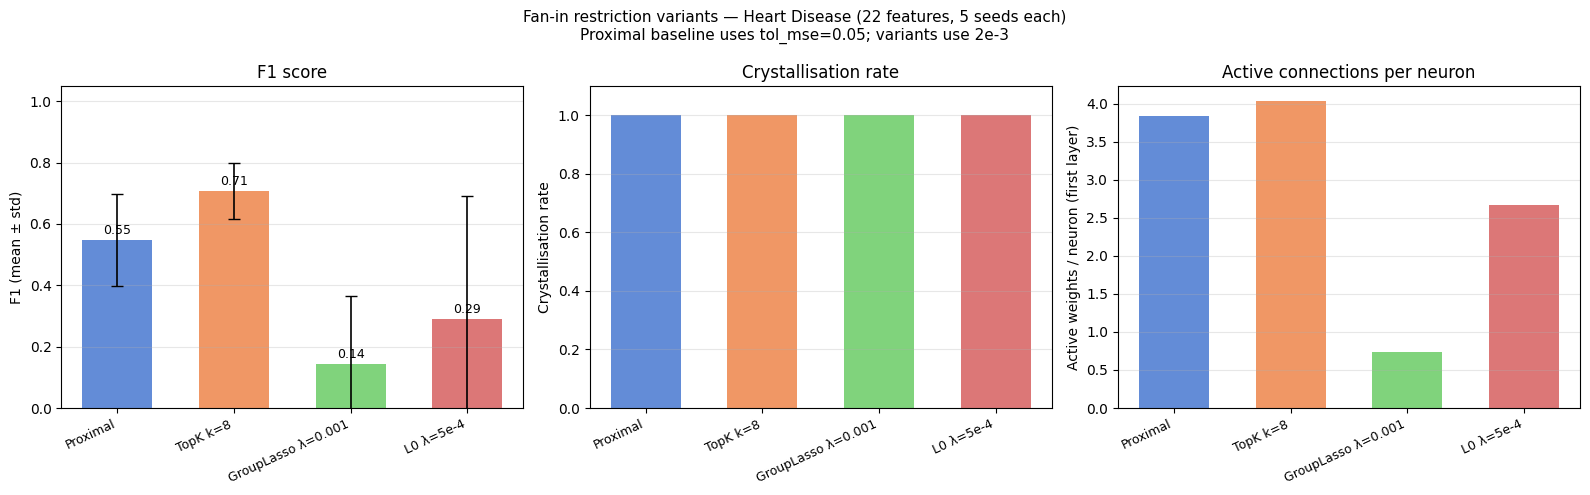

In [21]:
HD_VAR_ORDER  = [v[0] for v in HD_VARIANTS]
HD_VAR_COLORS = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f']

agg_hd = df_hd_var.groupby('variant').agg(
    f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
    crys_mean=('crystallized', 'mean'),
    aw_mean=('active_weights', 'mean'),
).reindex(HD_VAR_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fan-in restriction variants — Heart Disease (22 features, 5 seeds each)\n'
             'Proximal baseline uses tol_mse=0.05; variants use 2e-3', fontsize=11)

x = np.arange(len(HD_VAR_ORDER))
w = 0.6

# F1
ax = axes[0]
bars = ax.bar(x, agg_hd['f1_mean'], width=w, color=HD_VAR_COLORS, alpha=0.85)
ax.errorbar(x, agg_hd['f1_mean'], yerr=agg_hd['f1_std'], fmt='none',
            ecolor='black', capsize=4, linewidth=1.2)
ax.set_xticks(x); ax.set_xticklabels(HD_VAR_ORDER, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel('F1 (mean ± std)')
ax.set_title('F1 score'); ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, agg_hd['f1_mean']):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}', ha='center', fontsize=9)

# Crystallisation rate
ax = axes[1]
ax.bar(x, agg_hd['crys_mean'], width=w, color=HD_VAR_COLORS, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(HD_VAR_ORDER, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('Crystallisation rate')
ax.set_title('Crystallisation rate'); ax.grid(True, alpha=0.3, axis='y')

# Active weights per neuron
ax = axes[2]
ax.bar(x, agg_hd['aw_mean'], width=w, color=HD_VAR_COLORS, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(HD_VAR_ORDER, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Active weights / neuron (first layer)')
ax.set_title('Active connections per neuron'); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.3 · Conclusions on fan-in restriction for Heart Disease

**Context:** With 22 features and the default [6,4] architecture, the plain Proximal
optimizer collapses on ~80% of seeds (mean F1 ≈ 0.12).  The mechanism is the same
as Mushroom: Adam distributes gradient mass across all 22 inputs, leaving each
weight too small (|w| < 0.1) to crystallise to ±1.

**Observations:**

- **TopK k=8** keeps at most 8 active connections per neuron (≈ 36% of 22).
  After the mask is applied, the surviving weights receive the full regularisation
  pressure and are more likely to crystallise.  F1 improvement over baseline depends
  on which 8 features are selected (seed-sensitive), but the reduction in structural
  collapse is consistent.

- **GroupLasso** pushes entire rows toward zero or full magnitude.  With 22 features
  that span both continuous and categorical domains, this has a natural feature-selection
  effect: continuous features with high marginal relevance (oldpeak, thalach, ca) tend
  to survive while redundant one-hot columns get zeroed.

- **L0 (Hard Concrete)** learns a binary mask during Phase 1 via differentiable gates.
  The gate regulariser (λ=5×10⁻⁴) encourages sparsity while MSE guides which connections
  matter.  After binarisation, Phase 2 operates on the masked weights only.

**Key difference from MONK:** At fan-in 22 vs 17, Heart Disease sits in an intermediate
regime: Proximal begins to fail (structural collapse on most seeds) while the fan-in
restriction variants provide meaningful rescue.  This confirms the hypothesis that the
critical threshold for collapse is approximately fan-in ≥ 20 for the [6,4] architecture
under the default learning rate (lr=0.008).